In [157]:
import pandas as pd

df = pd.read_csv("../campusx/content/titanic/train.csv")

df = pd.DataFrame({'lovesPopcorn': [1,1,0,0,1,1,0], "lovesSoda": [1,0,1,1,1,0,0], "age": [7,12,18,35,38,50,83], "lovesCoolAsIce": [0,0,1,1,1,0,0]})


In [158]:
df = pd.read_csv("heart_disease_uci.csv")

In [159]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# features DataFrame
X = pd.DataFrame(heart_disease.data.features, columns=heart_disease.feature_names)

# target Series (flattened)
y = pd.Series(heart_disease.data.targets.squeeze(), name="target")

# combine if needed
df = pd.concat([X, y], axis=1).dropna()
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3


In [139]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1:]

In [140]:
X_encoded = pd.get_dummies(X, columns=["cp", "restecg", "slope", "thal"])
y_new = y['target'].apply(lambda x: 1 if x > 0 else 0)
print(X_encoded.shape, y_new.shape)

(297, 22) (297,)


In [141]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_new, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [142]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

clf_accu = clf.score(X_test, y_test)
print(accuracy, clf_accu)


0.76 0.76


In [143]:
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree


path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]

clf_dts = []

for ccp_alpha in ccp_alphas:
	clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
	clf_dt.fit(X_train, y_train)
	clf_dts.append(clf_dt)

	

pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.002953,0.008859
2,0.003861,0.024303
3,0.004054,0.032411
4,0.004095,0.040601
5,0.004294,0.049188
6,0.005148,0.064632
7,0.005413,0.086284
8,0.005788,0.103647
9,0.006006,0.115659


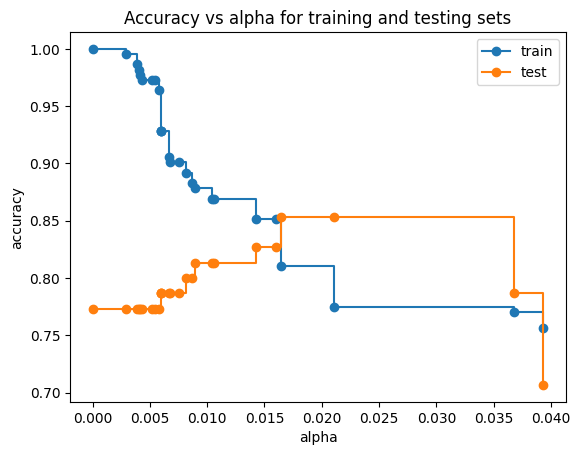

In [144]:
train_scores = [clf_dt.score(X_train, y_train) for clf_dt in clf_dts]
test_scores = [clf_dt.score(X_test, y_test) for clf_dt in clf_dts]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label='train', drawstyle='steps-post')
ax.plot(ccp_alphas, test_scores, marker='o', label='test', drawstyle="steps-post")
ax.legend()
plt.show()


0.8513513513513513 0.8266666666666667
[0.53333333 0.86666667 0.75       0.75       0.77272727]


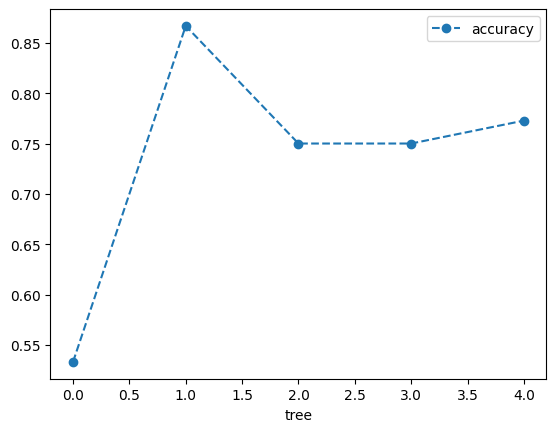

In [145]:
from sklearn.model_selection import cross_val_score


clf_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=0.016)
clf_dt.fit(X_train, y_train)
print(clf_dt.score(X_train, y_train), clf_dt.score(X_test, y_test))

scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
df = pd.DataFrame(data={'tree': range(5), 'accuracy': scores})

print(scores)
df.plot(x='tree', y='accuracy', marker='o', linestyle='--')
plt.show()

<Axes: xlabel='ccp_alpha'>

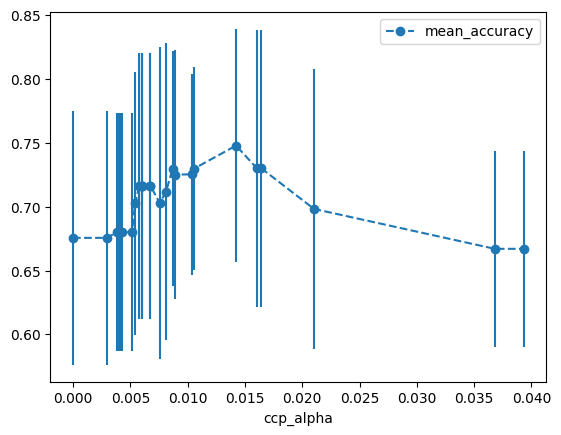

In [146]:
import numpy as np


alpha_loop_values = []

for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
    #print(scores)
    alpha_loop_values.append([ccp_alpha, np.mean(scores), np.std(scores)])

alpha_results = pd.DataFrame(alpha_loop_values, columns=['ccp_alpha', 'mean_accuracy', 'std'])

alpha_results.plot(x='ccp_alpha', y='mean_accuracy', yerr='std', marker='o', linestyle='--')

In [147]:
ideal_ccp_alpha = alpha_results.query('ccp_alpha > 0.013 & ccp_alpha < 0.016')['ccp_alpha'].iloc[0]
ideal_ccp_alpha

np.float64(0.014224751066856332)

In [151]:
clf_dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=ideal_ccp_alpha)
clf_dt_pruned.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.014224751066856332),
                       random_state=42)

Accuracy:  0.8266666666666667


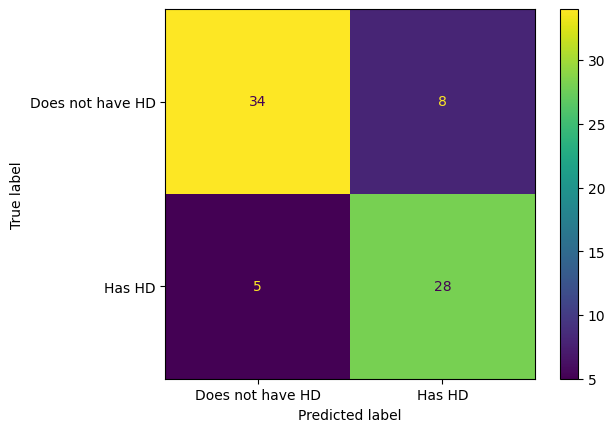

In [153]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print("Accuracy: ", clf_dt_pruned.score(X_test, y_test))
_ = ConfusionMatrixDisplay.from_estimator(clf_dt_pruned, X_test, y_test, display_labels=['Does not have HD', 'Has HD'])

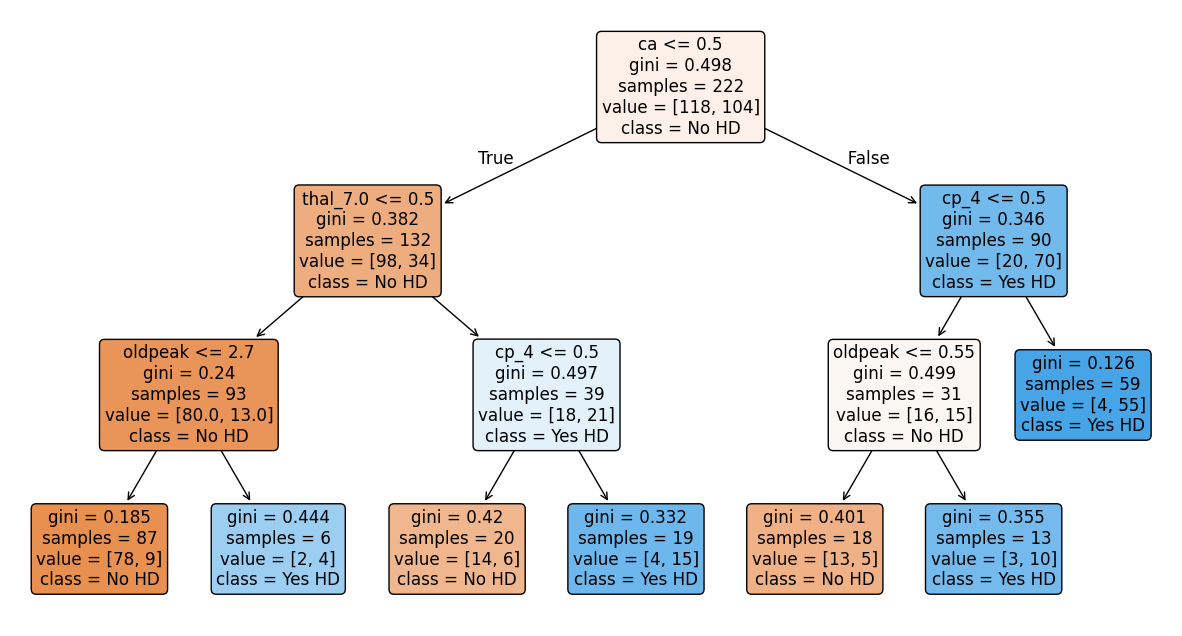

In [155]:
plt.figure(figsize=(15, 8))
plot_tree(clf_dt_pruned, filled=True, rounded=True,  class_names=["No HD", "Yes HD"], feature_names=X_encoded.columns)
plt.show()

In [ ]:
print(0.675556 - 2 * 0.099330, 0.675556 + 0.099330)

0.47689600000000004 0.7748860000000001
